In [2]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

project_dir = Path.cwd()
os.environ["USERPROFILE"] = str(project_dir)
os.environ["MPLCONFIGDIR"] = str(project_dir / ".cache" / "matplotlib")

if sys.version_info >= (3, 13):
    raise RuntimeError(
        "Use the 'Python 3.12 (tribe)' kernel. tribev2 depends on "
        "torch>=2.5.1,<2.7, which is not available for this Python."
    )

if importlib.util.find_spec("tribev2") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git",
    ])


In [3]:
from tribev2.demo_utils import TribeModel, download_file

d:\Documents\Staj\.venv-tribe\Lib\site-packages\neuralset\extractors\base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-07-07 18:11:30 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


In [8]:
from tribev2.plotting import PlotBrain
from huggingface_hub import snapshot_download
import pathlib
from pathlib import Path

CACHE_FOLDER = Path("./cache")
MODEL_FOLDER = CACHE_FOLDER / "tribev2-model"

snapshot_download(
    repo_id="facebook/tribev2",
    allow_patterns=["config.yaml", "best.ckpt"],
    local_dir=MODEL_FOLDER,
)

pathlib.PosixPath = pathlib.WindowsPath

model = TribeModel.from_pretrained(
    MODEL_FOLDER,
    cache_folder=CACHE_FOLDER,
)
plotter = PlotBrain(mesh="fsaverage5")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

d:\Documents\Staj\.venv-tribe\Lib\site-packages\neuralset\extractors\base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-07-07 18:21:34 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from cache\tribev2-model\best.ckpt


In [9]:
print(model)

infra=TaskInfra(folder='/checkpoint/sdascoli/results/tribe_release/half_depth/brain_model_config.subject_layers.subject_dropout=0.10,data.study.names=(Algonauts2025Bold,Lahner2024Bold,Lebel2023Bold,Wen2017)-ecdd89b2', cluster='auto', logs='{folder}/logs/{user}/%j', job_name='brain_model_config.subject_layers.subject_dropout=0.10,data.study.names=(Algonauts2025Bold,Lahner2024Bold,Lebel2023Bold,Wen2017)-ecdd89b2', timeout_min=4320, nodes=1, tasks_per_node=1, cpus_per_task=20, gpus_per_node=1, mem_gb=128.0, max_pickle_size_gb=None, slurm_constraint='volta32gb', slurm_partition='learnfair', slurm_account=None, slurm_qos=None, slurm_use_srun=False, slurm_additional_parameters=None, conda_env=None, workdir=None, permissions=511, version='1', mode='retry', keep_in_ram=False) data=Data(study=MultiStudyLoader(**
{ 'infra': None,
  'infra_timelines': { 'cluster': 'processpool',
                       'conda_env': None,
                       'cpus_per_task': None,
                       'folder'

C:\Users\auran\AppData\Local\Temp\ipykernel_8928\1278494369.py:20: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  pl.show()


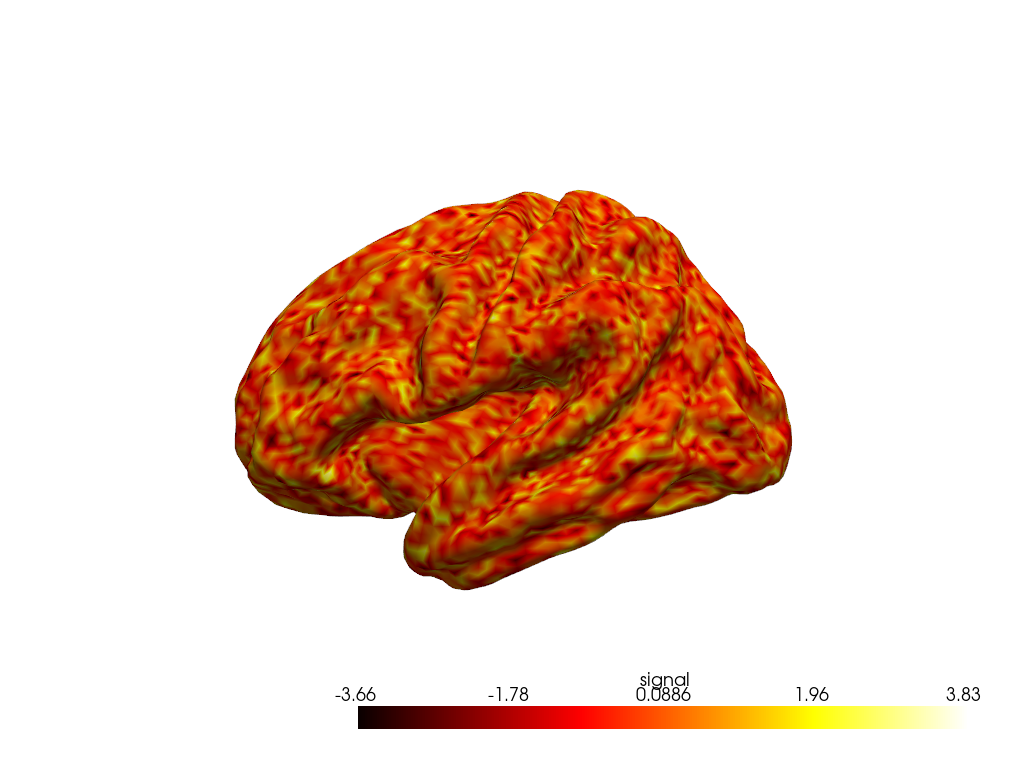

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

dummy = np.random.randn(len(plotter._mesh["both"]["bg_map"]))

mesh = plotter._mesh["left"]
vertices = mesh["coords"]
faces = mesh["faces"]
bg_map = mesh["bg_map"]

pv_faces = np.column_stack([np.full(len(faces), 3), faces])
brain = pv.PolyData(vertices, pv_faces)
brain.point_data["signal"] = dummy[: len(vertices)]

pl = pv.Plotter(notebook=True)
pl.add_mesh(brain, scalars="signal", cmap="hot", smooth_shading=True)
pl.set_background("white")
pl.view_vector((-1, 0, 0), viewup=(0, 0, 1))
pl.show()

C:\Users\auran\AppData\Local\Temp\ipykernel_8928\885193742.py:13: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  pl.show()


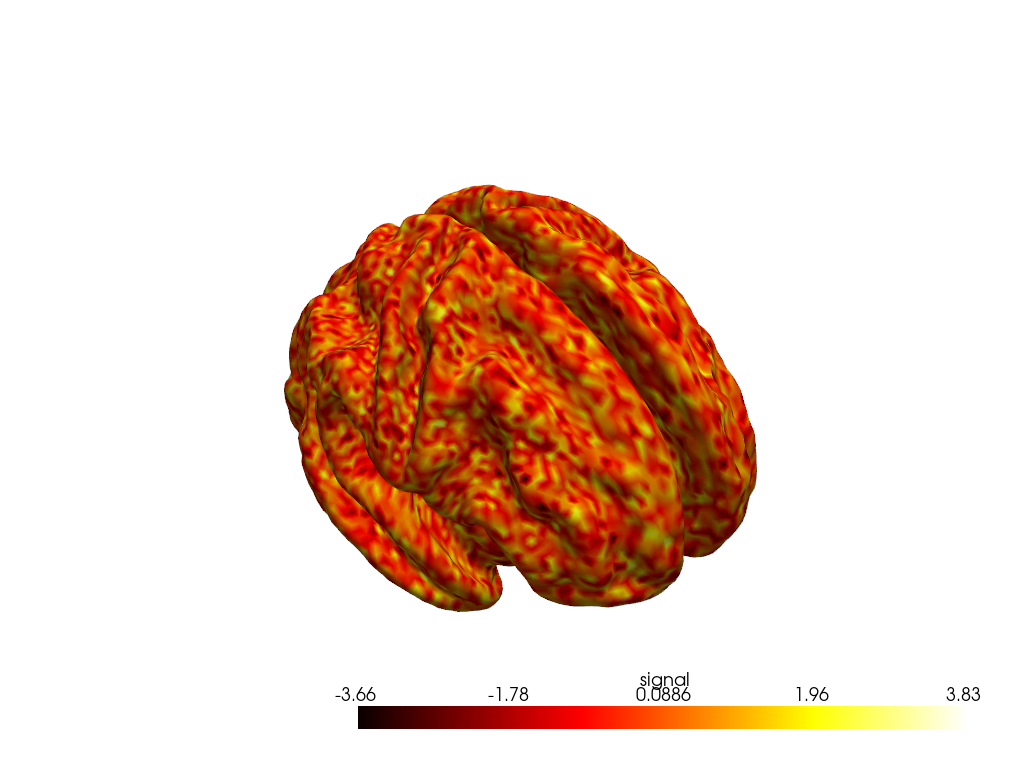

In [14]:
#Both hemispheres
mesh = plotter._mesh["both"]
vertices = mesh["coords"]
faces = mesh["faces"]

pv_faces = np.column_stack([np.full(len(faces), 3), faces])
brain = pv.PolyData(vertices, pv_faces)
brain.point_data["signal"] = dummy

pl = pv.Plotter(notebook=True)
pl.add_mesh(brain, scalars="signal", cmap="hot", smooth_shading=True)
pl.set_background("white")
pl.show()

In [10]:
print(type(model).__name__)
print(type(plotter).__name__)

TribeModel
PlotBrainPyvista


In [15]:
pip install pyvista

Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install trame


   ----------------------------------------  0/14 [trame-common]
   ----- ----------------------------------  2/14 [multidict]
   ----------- ----------------------------  4/14 [more-itertools]
   -------------------- -------------------  7/14 [yarl]
   ---------------------- -----------------  8/14 [trame-client]
   ---------------------- -----------------  8/14 [trame-client]
   ---------------------------- ----------- 10/14 [aiohttp]
   ---------------------------- ----------- 10/14 [aiohttp]
   ---------------------------- ----------- 10/14 [aiohttp]
   ---------------------------- ----------- 10/14 [aiohttp]
   ---------------------------- ----------- 10/14 [aiohttp]
   ---------------------------- ----------- 10/14 [aiohttp]
   ---------------------------- ----------- 10/14 [aiohttp]
   ------------------------------- -------- 11/14 [wslink]
   ------------------------------- -------- 11/14 [wslink]
   ---------------------------------- ----- 12/14 [trame-server]
   ------------

In [19]:
pip install pyvista[jupyter]

   ---------------------------------------- 0.0/831.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/831.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/831.8 kB ? eta -:--:--
   ------------ --------------------------- 262.1/831.8 kB ? eta -:--:--
   ------------------------- -------------- 524.3/831.8 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 831.8/831.8 kB 1.2 MB/s  0:00:00
   ---------------------------------------- 0.0/5.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/5.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/5.1 MB 1.4 MB/s eta 0:00:04
   ------ --------------------------------- 0.8/5.1 MB 1.5 MB/s eta 0:00:03
   -------- ------------------------------- 1.0/5.1 MB 1.5 MB/s eta 0:00:03
   ------------ --------------------------- 1.6/5.1 MB 1.5 MB/s eta 0:00:03
   -------------- ------------------------- 1.8/5.1 MB 1.5 MB/s eta 0:00:03
   ---------------- -------------------

In [21]:
import pyvista as pv
import numpy as np

pv.set_jupyter_backend("html")

mesh = plotter._mesh["both"]
vertices = mesh["coords"]
faces = mesh["faces"]
pv_faces = np.column_stack([np.full(len(faces), 3), faces])

brain = pv.PolyData(vertices, pv_faces)
brain.point_data["signal"] = np.random.randn(len(vertices))

pl = pv.Plotter(notebook=True)
pl.add_mesh(brain, scalars="signal", cmap="hot", smooth_shading=True)
pl.set_background("white")
pl.show()

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…